### Import Libraries

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### Load Dataset

In [36]:
df = pd.read_csv("Battery_dataset.csv")
df.head()

,battery_id,cycle,chI,chV,chT,disI,disV,disT,BCt,SOH,RUL
0,B5,1,1.440147,4.254682,23.988733,1.894407,3.273523,32.980834,1.986196,99.309790,219
1,B5,2,1.416595,4.159825,25.665347,1.829949,4.038741,32.257920,1.986240,99.311985,218
2,B5,3,1.420272,4.276323,25.407910,1.942105,3.214433,35.134801,1.984252,99.212608,217
3,B5,4,1.337680,4.236697,27.069757,2.073577,3.134529,32.082988,1.969236,98.461812,216
4,B5,5,1.263946,4.142791,26.478353,2.049885,3.729341,32.483154,1.974862,98.743106,215


### Create IMPROVED Target

In [37]:
y = df["RUL"]

### Feature Engineering

In [38]:
df["power_ch"] = df["chV"] * df["chI"]
df["power_dis"] = df["disV"] * df["disI"]

df["temp_diff"] = df["chT"] - df["disT"]
df["current_diff"] = df["chI"] - df["disI"]
df["voltage_diff"] = df["chV"] - df["disV"]

### Select Features (NO DATA LEAKAGE)

In [39]:
X = df[
    [
        "cycle",
        "chI", "chV", "chT",
        "disI", "disV", "disT",
        "power_ch", "power_dis",
        "temp_diff", "current_diff", "voltage_diff"
    ]
]

### Train-Test Split

In [40]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### Train Linear Regression

In [41]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

print("Linear Regression R2:", r2_score(y_test, lr_pred))

Linear Regression R2: 0.9288385649969747


### Train XGBoost (Improved)

In [42]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)

print("XGBoost R2:", r2_score(y_test, xgb_pred))

XGBoost R2: 0.8765151500701904


### Feature Importance (IMPORTANT)

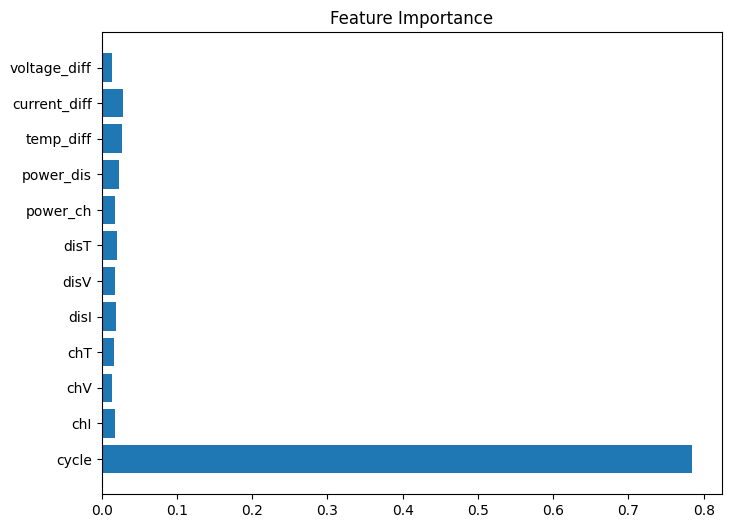

In [43]:
importance = xgb_model.feature_importances_

plt.figure(figsize=(8,6))
plt.barh(X.columns, importance)
plt.title("Feature Importance")
plt.show()

In [44]:
import joblib

joblib.dump(xgb_model, "xgb_model.pkl")

['xgb_model.pkl']

In [45]:
import os
print(os.getcwd())

C:\Users\nazim\OneDrive\Desktop\EV_Project\data
